In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner

from plot_eos_inference import load_posterior, plot_mr, plot_ml, plot_pressure, plot_pop, corner_plot, get_quantiles, r14_confidence_interval, l14_confidence_interval, mtov_confidence_interval, plot_mr_nofill, plot_pop_nofill, plot_cosmo

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }
fontsize=14

def pressure_confidence_interval(posterior):
    x = np.geomspace(0.5, 10, 100) # densities 
    x, quantiles, _ = get_quantiles(x, posterior["densities_EOS"] / 0.16, posterior["pressures_EOS"], posterior["weights"])

    lower = np.interp(3, x, quantiles[:, 0])
    median = np.interp(3, x, quantiles[:, 2])
    upper = np.interp(3, x, quantiles[:, 4])
    plus = upper-median
    minus = median-lower

    return f"{{{median:.0f}}}^{{+{plus:.0f}}}_{{-{minus:.0f}}}"


def confidence_interval(posterior, key):

    lower, median, upper = np.quantile(posterior[key], [0.025, 0.5, 0.975], weights=posterior["weights"], method="inverted_cdf")
    minus = median - lower
    plus = upper - median

    return f"{{{median:.2f}}}_{{-{minus:.2f}}}^{{+{plus:.2f}}}"

def confidence_interval_onedigit(posterior, key):

    lower, median, upper = np.quantile(posterior[key], [0.025, 0.5, 0.975], weights=posterior["weights"], method="inverted_cdf")
    minus = median - lower
    plus = upper - median

    return f"{{{median:.1f}}}_{{-{minus:.1f}}}^{{+{plus:.1f}}}"

## narrow ETL

In [33]:
directory = Path("../narrow_ETL")

posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5")
posterior_alt = load_posterior(directory / "cosmo_inference_withoutem" / "outdir" / "results.h5")

In [24]:
confidence_interval(posterior_alt, "Omega0")

'{0.33}_{-0.08}^{+0.10}'

In [37]:
print(l14_confidence_interval(posterior))
print(l14_confidence_interval(posterior_alt))

{371}^{+12}_{-11}
{372}^{+12}_{-12}


In [38]:
print(r14_confidence_interval(posterior))
print(r14_confidence_interval(posterior_alt))

{12.12}^{+0.08}_{-0.11}
{12.20}^{+0.07}_{-0.17}


In [5]:
print(confidence_interval(posterior["H0"], posterior["weights"]))
print(confidence_interval(posterior_alt["H0"], posterior_alt["weights"]))

{68.19}_{-0.86}^{+0.87}
{68.36}_{-0.75}^{+0.64}


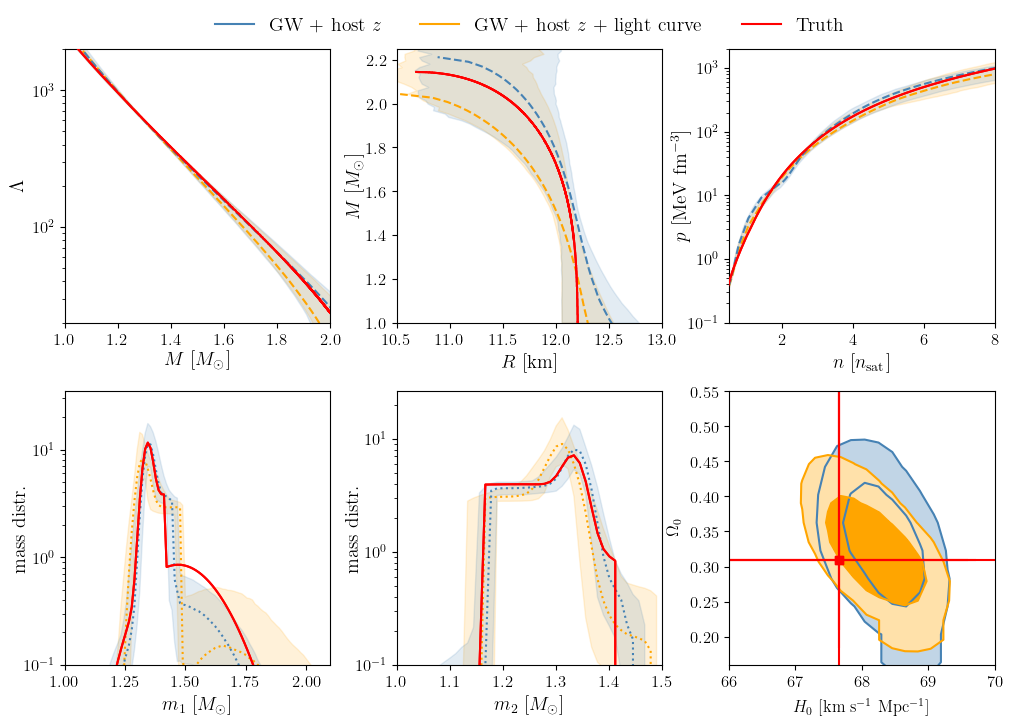

In [34]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
fig.subplots_adjust(wspace=0.25, hspace=0.25)


plot_ml(ax[0,0], posterior, color="orange")
plot_ml(ax[0,0], posterior_alt, color="steelblue")

plot_mr(ax[0,1], posterior, color="orange", plot_bestfit=True,)
plot_mr(ax[0,1], posterior_alt, color="steelblue",)

plot_pressure(ax[0,2], posterior, color="orange",)
plot_pressure(ax[0,2], posterior_alt, color="steelblue")

plot_pop(ax[1,:2], posterior, color="orange")
plot_pop(ax[1,:2], posterior_alt, color="steelblue")

ax[1, 1].set_xlim((1.0, 1.5))


plot_cosmo(ax[1, 2], posterior_alt, color="steelblue", labelpad=6)
plot_cosmo(ax[1, 2], posterior, color="orange", labelpad=6)
ax[1, 2].set_ylim((0.16, 0.55))
ax[1, 2].set_xlim((66, 70))
ax[1, 2].vlines([67.66], *ax[1,2].get_ylim(), color="red")
ax[1, 2].hlines([0.30966], *ax[1,2].get_xlim(), color="red")


lc1 = plt.plot([], [], color="steelblue")[0]
lc2 = plt.plot([], [], color="orange")[0]
lc3 = plt.plot([], [], color="red")[0]

ax[0,1].legend(
    [lc1, lc2, lc3], 
    ["GW + host $z$", "GW + host $z$ + light curve", "Truth"], 
    fontsize=14, 
    framealpha=1.,
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    frameon=False, ncol=3
)


fig.savefig('../../figures/cosmo_inference_narrow_ETL.pdf', dpi=250, bbox_inches="tight")


(array([  36.,  159.,  715., 2014., 2288., 1050.,  478.,  173.,   64.,
          23.]),
 array([1.26290839, 1.29599738, 1.32908637, 1.36217537, 1.39526436,
        1.42835335, 1.46144234, 1.49453134, 1.52762033, 1.56070932,
        1.59379831]),
 <BarContainer object of 10 artists>)

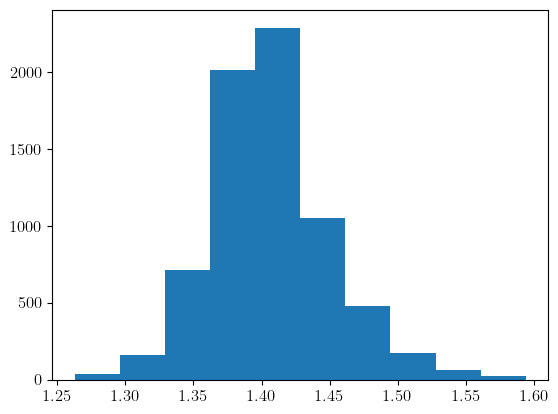

In [7]:
plt.hist(posterior["k_coll"])

NameError: name 'posterior_alt' is not defined

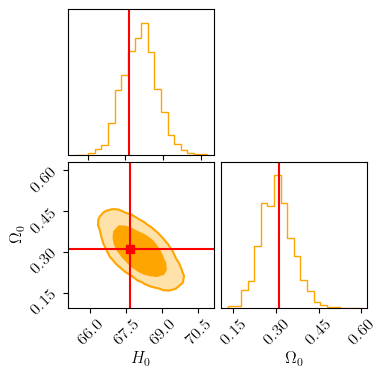

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(4,4))

fig = corner_plot(posterior, ["H0", "Omega0"], fig=fig, color="orange")
fig = corner_plot(posterior_alt, ["H0", "Omega0"], fig=fig, color="steelblue")
ax[1,0].set_xlabel("$H_0$ [km s$^{-1}$ Mpc$^{-1}$]")

#handles = [ax[0,1].plot([], [], color=c)[0] for c in ["orange", "lightblue"]]
#labels = ["incl. KN posterior", "GW + redshift only"]
#ax[0,1].legend(handles=handles, labels=labels, framealpha=1, fancybox=False)

#fig.savefig("cosmoposterior_wo_em.pdf", dpi=250, bbox_inches="tight")

(278.83724294402344, 473.6512224855747)

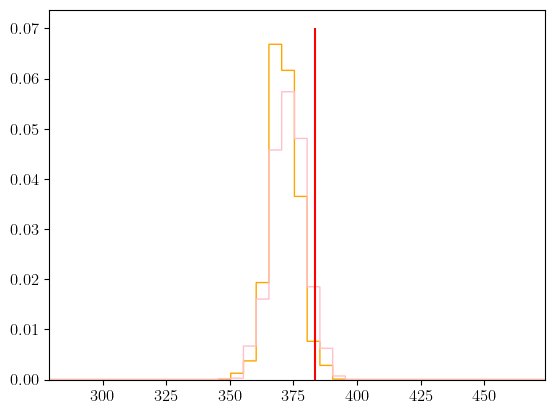

In [7]:
mx = 1.4

l14 = np.array([np.interp(mx, posterior["masses_EOS"][j], posterior["lambdas_EOS"][j]) for j in range(7000)])
l14_alt = np.array([np.interp(mx, posterior_alt["masses_EOS"][j], posterior_alt["lambdas_EOS"][j]) for j in range(7000)])
r14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["radii_EOS"][j]) for j in range(7000)])
r14_alt = np.array([np.interp(1.4, posterior_alt["masses_EOS"][j], posterior_alt["radii_EOS"][j]) for j in range(7000)])
mtov = np.array([ posterior["masses_EOS"][j].max() for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])
plt.hist(l14_alt, color="pink", density=True, histtype="step", bins=bins, weights=posterior["weights"])

plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14.min()*0.8, 1.2*l14.max()))

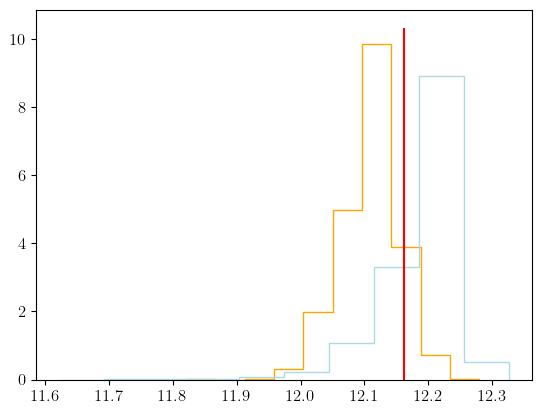

In [55]:
plt.hist(r14, weights=posterior["weights"], color='orange', density=True, histtype="step")
plt.hist(r14_alt, weights=posterior_alt["weights"], color='lightblue', density=True, histtype="step")

plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")

# Other cosmo plots

In [10]:
narrow_ETL = load_posterior(Path("../narrow_ETL") / "cosmo_inference" / "outdir" / "results.h5")
wide_ETL = load_posterior(Path("../wide_ETL") / "cosmo_inference" / "outdir" / "results.h5")
narrow_ETT = load_posterior(Path("../narrow_ETT") / "cosmo_inference" / "outdir" / "results.h5")
wide_ETT = load_posterior(Path("../wide_ETT") / "cosmo_inference" / "outdir" / "results.h5")

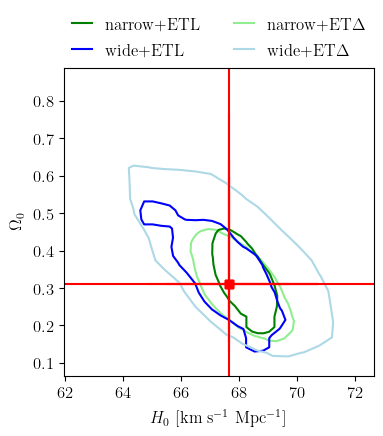

In [7]:
fig, ax = plt.subplots(1,1, figsize=(4,4))

plot_cosmo(ax, narrow_ETT, color="lightgreen", fill_contours=False, levels=[0.95], linestyle="solid")
plot_cosmo(ax, narrow_ETL, color="green", fill_contours=False, levels=[0.95],)
plot_cosmo(ax, wide_ETL, color="blue", fill_contours=False, levels=[0.95],)
plot_cosmo(ax, wide_ETT, color="lightblue", fill_contours=False, levels=[0.95], linestyle="solid")


lc1 = plt.plot([], [], color="green")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="lightgreen")[0]
lc4 = plt.plot([], [], color="lightblue")[0]
ax.legend(
    [lc1, lc2, lc3, lc4], 
    ["narrow+ETL", "wide+ETL", "narrow+ET$\\Delta$", "wide+ET$\\Delta$"], 
    handlelength=1.2, handleheight=1.2, fontsize=12,
    bbox_to_anchor=[0.5, 0.98], loc='lower center', frameon=False, ncol=2
)

fig.savefig("../../figures/cosmo_inference_all.pdf", dpi=250, bbox_inches="tight")

In [20]:
with open("table.tex", "w") as out:
    #L14

    line = "$\\Lambda_{1.4}$ &"
    for posterior in [narrow_ETL, wide_ETL, narrow_ETT, wide_ETT]:
        line += f" ${l14_confidence_interval(posterior)}$ &"
    line += f"{np.interp(1.4, m_eos, l_eos):.0f} \\\\[0.5em] \n"
    out.write(line)

    #R14

    line = "$R_{1.4}$ \\newline [km] &"
    for posterior in [narrow_ETL, wide_ETL, narrow_ETT, wide_ETT]:
        line += f" ${r14_confidence_interval(posterior)}$ &"
    line += f"{np.interp(1.4, m_eos, r_eos):.2f} \\\\[0.5em] \n"
    out.write(line)

    # MTOV

    line = "$M_{\\rm{TOV}}$ \\newline $[\\msun]$ &"
    for posterior in [narrow_ETL, wide_ETL, narrow_ETT, wide_ETT]:
        line += f" ${mtov_confidence_interval(posterior)}$ &"
    line += f"{m_eos.max():.2f} \\\\[0.5em] \n"
    out.write(line)

    # p3snat

    line = "$p(3\\nsat)$ [MeV~fm$^{{-3}}$] &"
    for posterior in [narrow_ETL, wide_ETL, narrow_ETT, wide_ETT]:
        line += f" ${pressure_confidence_interval(posterior)}$ &"
    line += f"{np.interp(3, n_eos/0.16, p_eos):.0f} \\\\[0.5em] \n"
    out.write(line)

    out.write("\\midrule \n")

    # H_0

    line = "$H_0$ [km~s$^{-1}$ Mpc$^{-1}$] &"
    for posterior in [narrow_ETL, wide_ETL, narrow_ETT, wide_ETT]:
        line += f" ${confidence_interval_onedigit(posterior, 'H0')}$ &"
    line += f" 67.66 \\\\[0.5em] \n"
    out.write(line)

    # Omega_0
    line = "$\\Omega_0$ &"
    for posterior in [narrow_ETL, wide_ETL, narrow_ETT, wide_ETT]:
        line += f" ${confidence_interval(posterior, 'Omega0')}$ &"
    line += f" 0.31 \\\\[0.5em] \n"
    out.write(line)

    out.write("\\bottomrule \n")


## wide ETL

In [2]:
directory = Path("../wide_ETL")

posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5")

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


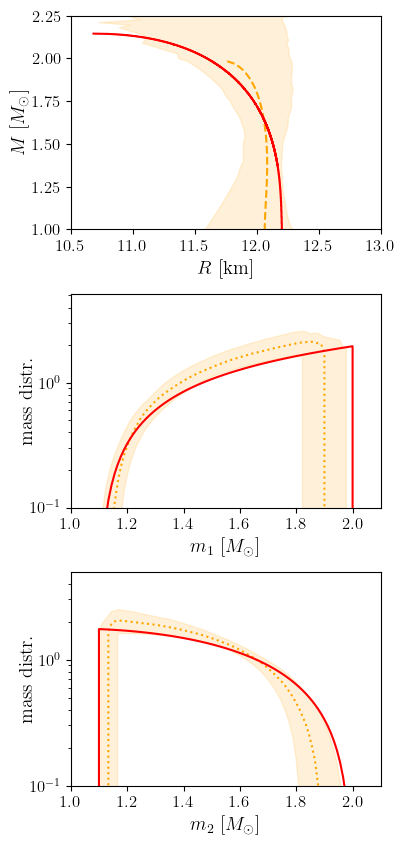

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior, color="orange")

plot_pop(ax[1:], posterior, color="orange")

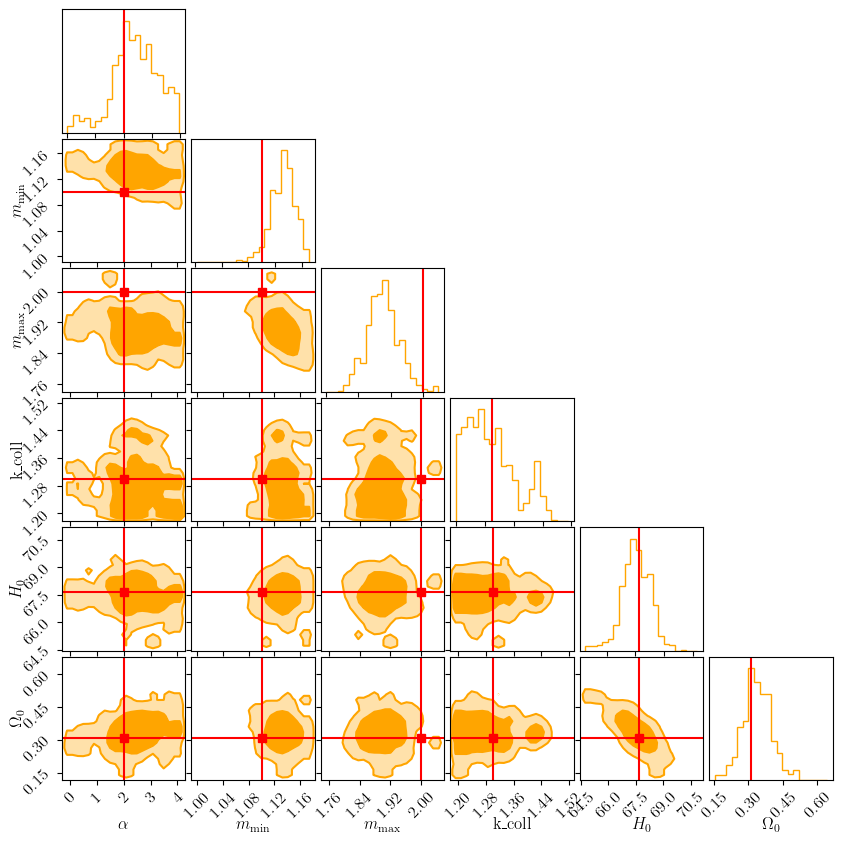

In [4]:
fig = corner_plot(posterior, ["alpha", "m_min", "m_max", "k_coll", "H0", "Omega0"], color="orange")

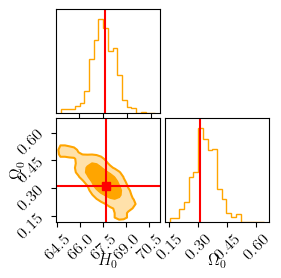

In [5]:
fig = corner_plot(posterior, ["H0", "Omega0"], color='orange')

In [6]:
print(confidence_interval(posterior["H0"], weights=posterior["weights"]))
print(confidence_interval(posterior["Omega0"], weights=posterior["weights"]))

{67.51}_{-1.72}^{+1.43}
{0.34}_{-0.13}^{+0.15}


(356.99489604243854, 816.3773025152393)

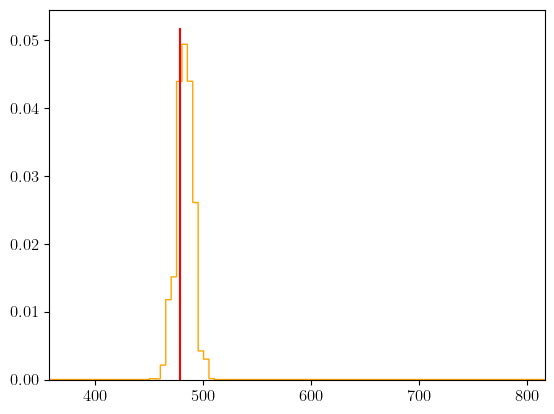

In [13]:
mx = 1.35

l14 = np.array([np.interp(mx, posterior["masses_EOS"][j], posterior["lambdas_EOS"][j]) for j in range(7000)])
r14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["radii_EOS"][j]) for j in range(7000)])
mtov = np.array([ posterior["masses_EOS"][j].max() for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14.min()*0.8, l14.max()*1.6))

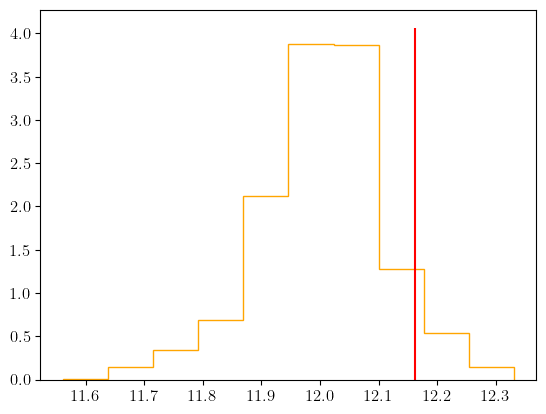

In [14]:
plt.hist(r14, weights=posterior["weights"], color='orange', density=True, histtype="step")

plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")

(array([ 382.,  566.,  712.,  941.,  933., 1245., 1295.,  583.,  319.,
          24.]),
 array([1.20008269, 1.22935636, 1.25863003, 1.28790369, 1.31717736,
        1.34645103, 1.3757247 , 1.40499837, 1.43427203, 1.4635457 ,
        1.49281937]),
 <BarContainer object of 10 artists>)

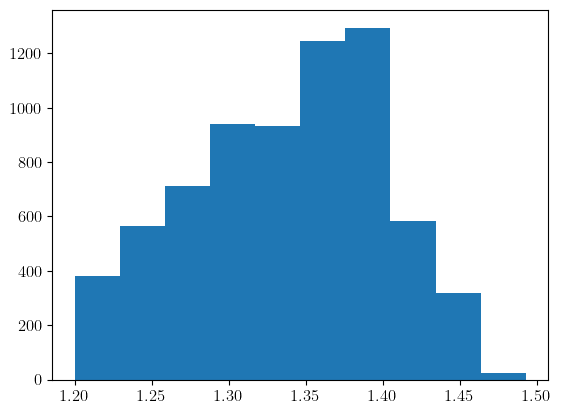

In [8]:
plt.hist(posterior["k_coll"])

# Narrow ETT

In [31]:
directory = Path("../narrow_ETT")
posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5")

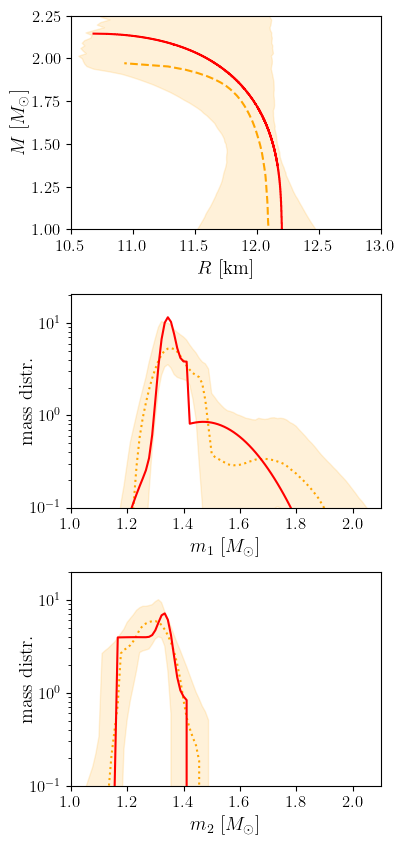

In [32]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)



plot_mr(ax[0], posterior, color="orange")
# plot_mr(ax[0], posterior_noem, color="pink")

plot_pop(ax[1:], posterior, color="orange")
# plot_pop(ax[1:], posterior_noem, color="pink")

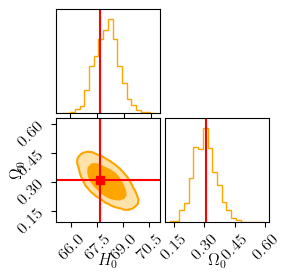

In [18]:
fig = corner_plot(posterior, ["H0", "Omega0"], color='orange')

(273.174964815691, 491.63306529376337)

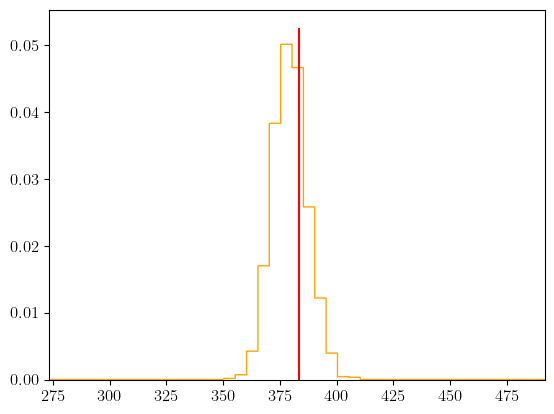

In [19]:
l14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(1.4, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14.min()*0.8, l14.max()*1.2))

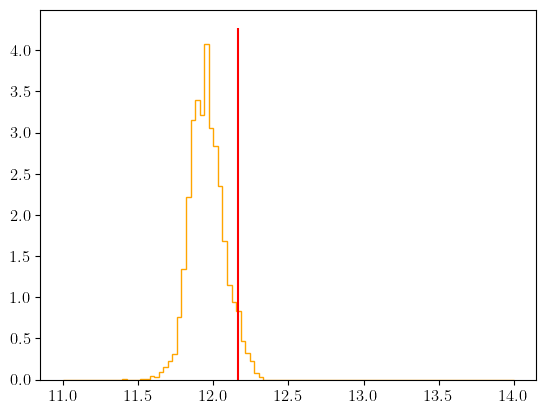

In [20]:
r14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["radii_EOS"][j]) for j in range(7000)])


bins = np.linspace(11, 14, 100)
plt.hist(r14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")


In [ ]:
print(confidence_interval(posterior["H0"], posterior["weights"]))

## wide ETT

In [33]:
directory = Path("../wide_ETT")

posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5")


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


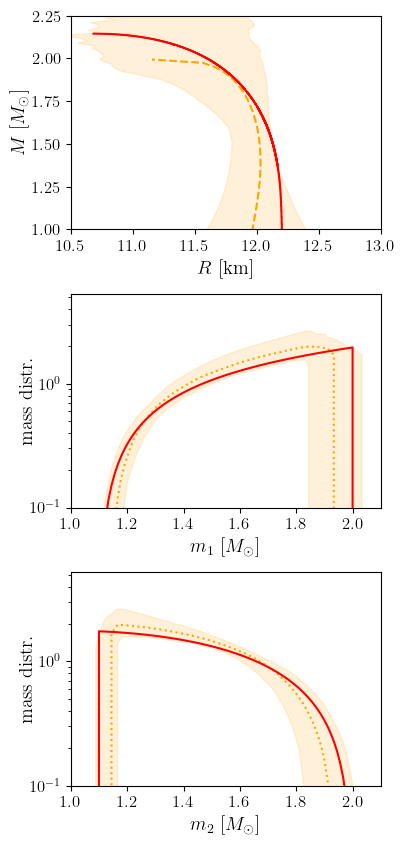

In [34]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior, color="orange")

plot_pop(ax[1:], posterior, color="orange")

(12.302155702123791, 84.78955888531591)

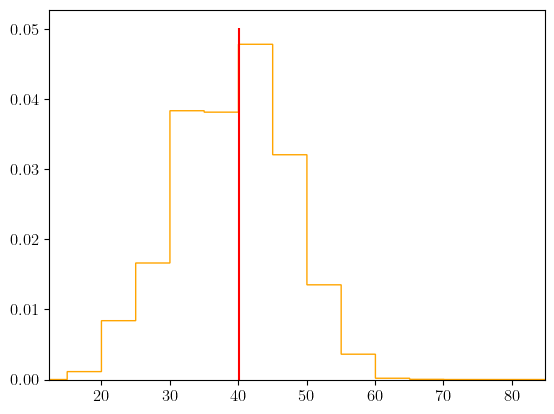

In [22]:
mx = 1.9

l14 = np.array([np.interp(mx, posterior["masses_EOS"][j], posterior["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14.min()*0.8, l14.max()*1.2))

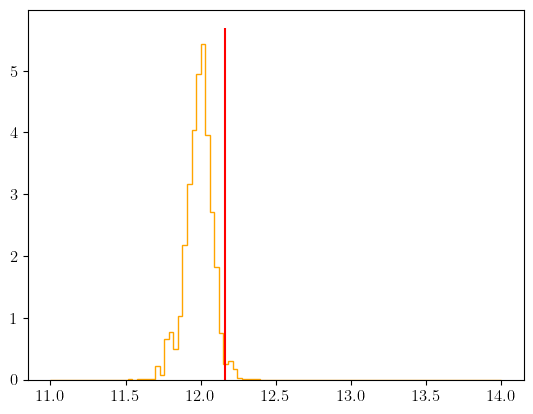

In [23]:
r14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["radii_EOS"][j]) for j in range(7000)])


bins = np.linspace(11, 14, 100)
plt.hist(r14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")


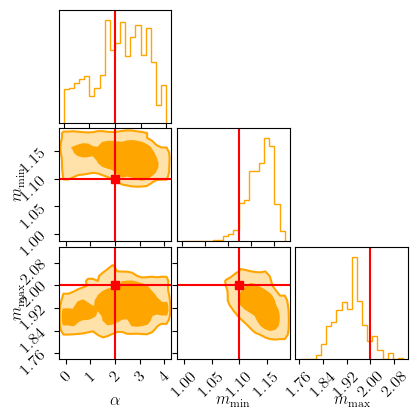

In [24]:
fig = corner_plot(posterior, ["alpha", "m_min", "m_max"], color="orange")


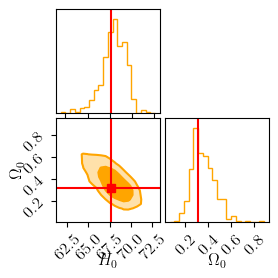

In [25]:
fig = corner_plot(posterior, ["H0", "Omega0"], color='orange')


# Test mass distributions

In [3]:
from jesterTOV.inference.population.populations import massratiopowerlaw_logpdf, MassRatioPowerLaw, recycledbinary_logpdf
import jax


def cred_contour(xx, yy, pdf):

    integrals = np.zeros(400)
    limits = np.linspace(0, pdf.max(), 400)

    for j, limit in enumerate(limits):

        new_pdf = pdf.copy()
        new_pdf[new_pdf<=limit] = 0
        integrals[j] = np.sum(new_pdf * (xx[0,0]-xx[0,1])**2)
    
    return np.interp([0.5], integrals[::-1], limits[::-1])

    

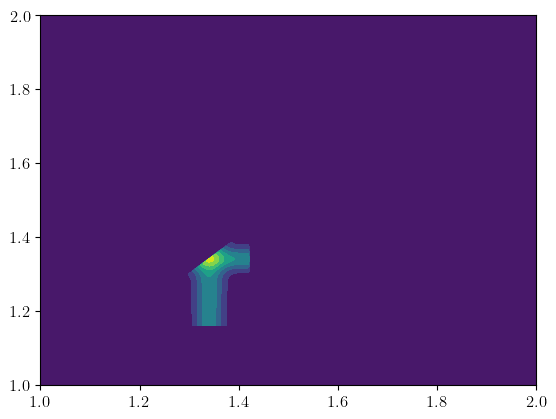

In [4]:


m_arr = np.linspace(1,2, 501)
xx, yy = np.meshgrid(m_arr, m_arr)

pdf = np.exp(recycledbinary_logpdf(xx, yy, dict(mu_1=1.34, mu_2=1.43, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42)))
#pdf[xx<yy] = 0

plt.contourf(m_arr, m_arr, pdf)

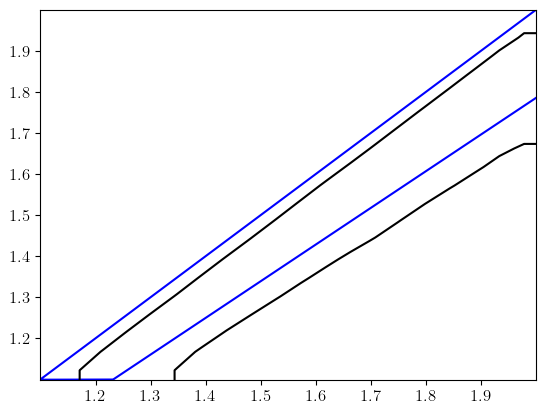

In [9]:
from jesterTOV.inference.population.populations import massratiopowerlaw_logpdf, MassRatioPowerLaw
import jax

m1, m2 = MassRatioPowerLaw(jax.random.key(424), dict(alpha=3, m_min=1.1, m_max=2.0), 600_000)

m_arr = np.linspace(1,2, 701)
xx, yy = np.meshgrid(m_arr, m_arr)

pdf = np.exp(massratiopowerlaw_logpdf(xx, yy, dict(alpha=3, m_min=1.1, m_max=2.0)))
levels = cred_contour(xx, yy, pdf,)

#pdf[xx<yy] = 0

plt.contour(m_arr, m_arr, pdf, levels=levels, colors="blue")
corner.hist2d(m1, m2, levels=[0.5], color="black", plot_density=False, plot_datapoints=False, fill_contours=False, no_fill_contours=True, smooth=True)

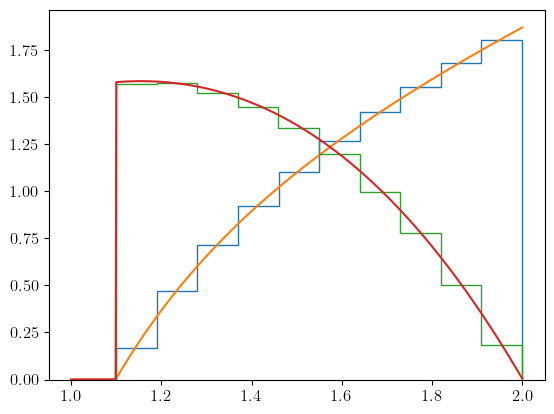

In [10]:
plt.hist(m1, density=True, histtype="step")
plt.plot(m_arr, np.sum(pdf, axis=0) * (m_arr[1] - m_arr[0]))

plt.hist(m2, density=True, histtype="step")
plt.plot(m_arr, np.sum(pdf, axis=1) * (m_arr[1] - m_arr[0]))

(array([0.65281688, 2.61126752, 3.91690127, 2.61126752, 0.65281688,
        2.61126752, 4.56971815, 1.30563376, 0.65281688, 3.91690127]),
 array([0.56953493, 0.61208557, 0.65463621, 0.69718686, 0.7397375 ,
        0.78228814, 0.82483878, 0.86738943, 0.90994007, 0.95249071,
        0.99504135]),
 [<matplotlib.patches.Polygon at 0x7f0fe068e410>])

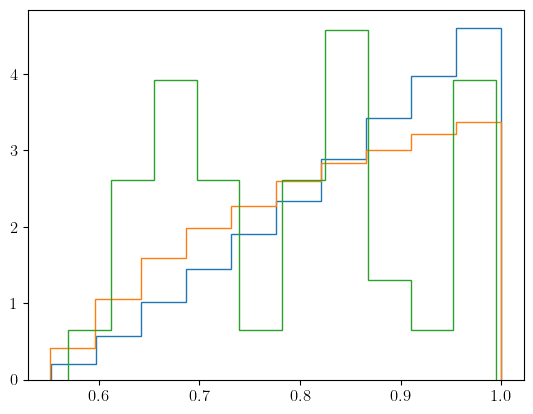

In [11]:
m1, m2 = MassRatioPowerLaw(jax.random.key(42), dict(alpha=2.0, m_min=1.1, m_max=2.0), 100_000)
plt.hist(m2/m1, histtype="step", density=True)

m1, m2 = MassRatioPowerLaw(jax.random.key(42), dict(alpha=0.0, m_min=1.1, m_max=2.0), 100_000)
plt.hist(m2/m1, histtype="step", density=True)

events = pd.read_csv("../../eos_inference/wide_ETL/events.dat", sep=" ")
plt.hist(events["mass_2"] / events["mass_1"], histtype="step", density=True)